<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/101025_FND_for_CoNV_excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from openpyxl import Workbook
from openpyxl.utils import get_column_letter

# Create workbook and active worksheet
wb = Workbook()
ws = wb.active
ws.title = "FND Research Data"

# Define the headers for FND research
headers = [
    "Patient ID",
    "Age",
    "Gender",
    "Eye Treated (Right/Left/Both)",
    "Indication for FND",
    "Date of Procedure",
    "Needle Gauge",
    "Diathermy Current Setting (mA)",
    "Duration of Current Application (seconds)",
    "Number of Vessels Treated",
    "Pre-treatment Vessel Status (Grading)",
    "Vessel Closure Success (Yes/No)",
    "Follow-up Time (days)",
    "Complications",
    "Visual Acuity Before",
    "Visual Acuity After",
    "Additional Treatments",
    "Comments / Notes"
]

# Add headers to the first row
for col_num, header in enumerate(headers, 1):
    col_letter = get_column_letter(col_num)
    ws[f"{col_letter}1"] = header

# Optionally set column widths for better readability
column_widths = [15, 5, 10, 20, 25, 15, 12, 25, 30, 20, 25, 20, 20, 30, 20, 20, 25, 40]
for i, width in enumerate(column_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = width

# Save workbook
wb.save("FND_Research_Data.xlsx")

print("Excel file 'FND_Research_Data.xlsx' created successfully.")


Excel file 'FND_Research_Data.xlsx' created successfully.


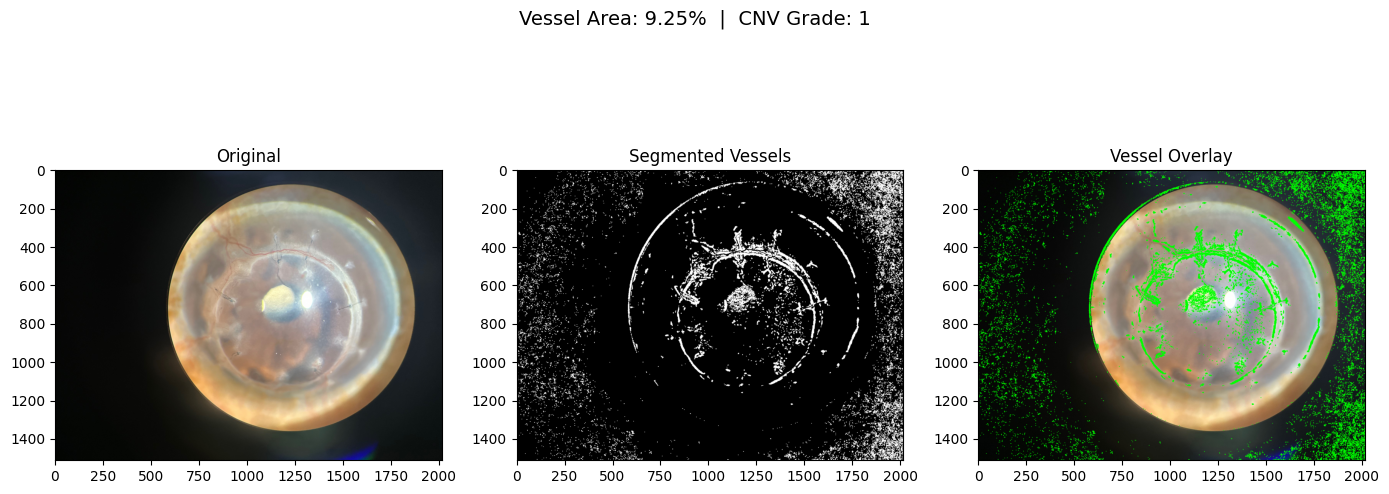

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- LOAD IMAGE ---
img_path = "/content/drive/MyDrive/Postpk Prabhakar.jpg"   # replace with your image path
img = cv2.imread(img_path)

# --- CONVERT TO GRAYSCALE ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- ENHANCE CONTRAST (CLAHE) ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# --- MORPHOLOGICAL TOP-HAT (HIGHLIGHT VESSELS) ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLD USING OTSU'S METHOD ---
_, binary = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- REMOVE SMALL NOISE ---
cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

# --- CALCULATE VESSEL AREA PERCENTAGE ---
total_pixels = cleaned.size
vessel_pixels = np.count_nonzero(cleaned)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

cnv_grade = assign_cnv_grade(vessel_percent)

# --- OVERLAY VESSELS ON ORIGINAL IMAGE ---
overlay = img.copy()
overlay[cleaned > 0] = [0, 255, 0]  # Green vessels

# --- DISPLAY RESULTS ---
plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(cleaned, cmap='gray'); plt.title("Segmented Vessels")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Vessel Overlay")

plt.suptitle(f"Vessel Area: {vessel_percent:.2f}%  |  CNV Grade: {cnv_grade}", fontsize=14)
plt.tight_layout()
plt.show()


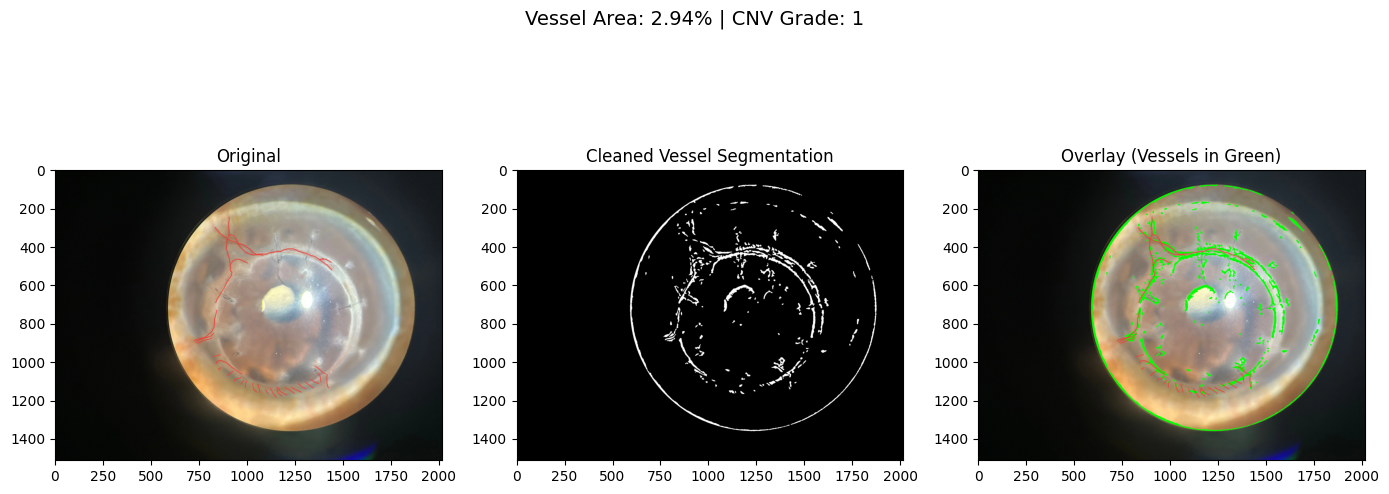

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- LOAD IMAGE ---
img_path = "/content/drive/MyDrive/Postpk Prabhakar annotated.jpg"   # replace with your image path
img = cv2.imread(img_path)

# --- CONVERT TO GRAYSCALE ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- ENHANCE CONTRAST (CLAHE) ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# --- REMOVE BACKGROUND ILLUMINATION (using large Gaussian blur) ---
background = cv2.GaussianBlur(enhanced, (55,55), 0)
no_bg = cv2.subtract(enhanced, background)

# --- TOP-HAT FILTER TO EMPHASIZE VESSELS ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
tophat = cv2.morphologyEx(no_bg, cv2.MORPH_TOPHAT, kernel)

# --- DENOISE (Median Blur to suppress salt-and-pepper noise) ---
denoised = cv2.medianBlur(tophat, 5)

# --- OTSU THRESHOLDING ---
_, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- MORPHOLOGICAL CLEANING ---
# Remove small dots & refine vessels
cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

# --- REMOVE VERY SMALL OBJECTS (ISOLATED NOISE) ---
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
min_area = 50  # minimum pixel area to keep (adjust as needed)
mask = np.zeros_like(cleaned)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        mask[labels == i] = 255

# --- CALCULATE VESSEL AREA ---
vessel_pixels = np.count_nonzero(mask)
total_pixels = mask.size
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- CNV GRADING ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

cnv_grade = assign_cnv_grade(vessel_percent)

# --- OVERLAY ON ORIGINAL IMAGE ---
overlay = img.copy()
overlay[mask > 0] = [0, 255, 0]

# --- DISPLAY RESULTS ---
plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Cleaned Vessel Segmentation")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Overlay (Vessels in Green)")

plt.suptitle(f"Vessel Area: {vessel_percent:.2f}% | CNV Grade: {cnv_grade}", fontsize=14)
plt.tight_layout()
plt.show()


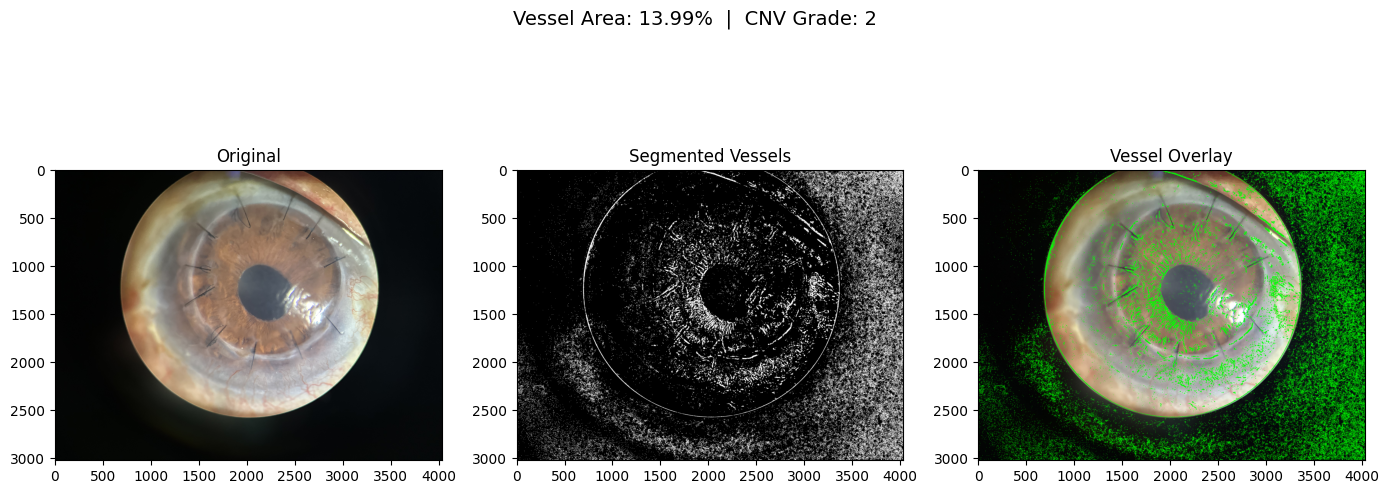

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- LOAD IMAGE ---
img_path = "/content/drive/MyDrive/Postpk nataraju.jpg"   # replace with your image path
img = cv2.imread(img_path)

# --- CONVERT TO GRAYSCALE ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- ENHANCE CONTRAST (CLAHE) ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# --- MORPHOLOGICAL TOP-HAT (HIGHLIGHT VESSELS) ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLD USING OTSU'S METHOD ---
_, binary = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- REMOVE SMALL NOISE ---
cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

# --- CALCULATE VESSEL AREA PERCENTAGE ---
total_pixels = cleaned.size
vessel_pixels = np.count_nonzero(cleaned)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

cnv_grade = assign_cnv_grade(vessel_percent)

# --- OVERLAY VESSELS ON ORIGINAL IMAGE ---
overlay = img.copy()
overlay[cleaned > 0] = [0, 255, 0]  # Green vessels

# --- DISPLAY RESULTS ---
plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(cleaned, cmap='gray'); plt.title("Segmented Vessels")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Vessel Overlay")

plt.suptitle(f"Vessel Area: {vessel_percent:.2f}%  |  CNV Grade: {cnv_grade}", fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
pip install opencv-python numpy matplotlib scikit-image


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
from scipy.ndimage import distance_transform_edt

def analyze_corneal_neovascularization(img_path, show_plots=True):
    # --- Load Image ---
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {img_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Enhance Contrast ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # --- Top-Hat Morphology ---
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
    tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

    # --- Threshold ---
    _, binary = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # --- Remove Noise ---
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

    # --- Vessel Area Calculation ---
    total_pixels = cleaned.size
    vessel_pixels = np.count_nonzero(cleaned)
    vessel_percent = (vessel_pixels / total_pixels) * 100

    # --- Skeleton & Width (Depth Estimation) ---
    skeleton = skeletonize(cleaned // 255)
    dist_map = distance_transform_edt(cleaned)
    width_map = dist_map * 2
    vessel_widths = width_map[skeleton > 0]
    mean_width = np.mean(vessel_widths) if len(vessel_widths) > 0 else 0
    depth = "stromal" if mean_width > 3 else "superficial"

    # --- Center & Peripheral Mask (Location) ---
    h, w = cleaned.shape
    cx, cy = w // 2, h // 2
    radius = min(cx, cy)
    center_mask = np.zeros_like(cleaned)
    cv2.circle(center_mask, (cx, cy), radius//3, 255, -1)
    peripheral_mask = np.zeros_like(cleaned)
    cv2.circle(peripheral_mask, (cx, cy), radius, 255, -1)
    peripheral_mask = cv2.subtract(peripheral_mask, center_mask)

    central_vessels = np.count_nonzero(cv2.bitwise_and(cleaned, cleaned, mask=center_mask))
    peripheral_vessels = np.count_nonzero(cv2.bitwise_and(cleaned, cleaned, mask=peripheral_mask))

    # --- Quadrant Analysis ---
    quadrants = {
        "superior": ((0, 0), (w, cy)),
        "inferior": ((0, cy), (w, h)),
        "nasal": ((0, 0), (cx, h)),
        "temporal": ((cx, 0), (w, h))
    }
    quadrant_vessel_counts = {}
    for name, ((x1, y1), (x2, y2)) in quadrants.items():
        mask = np.zeros_like(cleaned)
        mask[y1:y2, x1:x2] = 255
        count = np.count_nonzero(cv2.bitwise_and(cleaned, cleaned, mask=mask))
        quadrant_vessel_counts[name] = count

    # --- Tortuosity ---
    label_img = label(skeleton)
    tortuosities = []
    for region in regionprops(label_img):
        coords = region.coords
        if len(coords) < 5:
            continue
        length = len(coords)
        p0, pN = coords[0], coords[-1]
        straight = np.linalg.norm(np.array(p0) - np.array(pN))
        tortuosity = length / (straight + 1e-5)
        tortuosities.append(tortuosity)
    avg_tortuosity = np.mean(tortuosities) if len(tortuosities) > 0 else 0

    # --- Grid-Based Density Map ---
    grid_size = 4
    cell_h, cell_w = h // grid_size, w // grid_size
    density_map = np.zeros((grid_size, grid_size))
    for i in range(grid_size):
        for j in range(grid_size):
            cell = cleaned[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            density_map[i, j] = np.count_nonzero(cell) / cell.size * 100

    if show_plots:
        plt.figure(figsize=(14, 6))
        plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
        plt.subplot(1, 3, 2); plt.imshow(cleaned, cmap='gray'); plt.title("Segmented Vessels")
        plt.subplot(1, 3, 3); plt.imshow(density_map, cmap='hot'); plt.colorbar(); plt.title("Vessel Density Map")
        plt.suptitle(f"Area: {vessel_percent:.2f}% | Depth: {depth} | Tortuosity: {avg_tortuosity:.2f}")
        plt.tight_layout()
        plt.show()

    return {
        "vessel_percent": vessel_percent,
        "depth_estimate": depth,
        "mean_vessel_width": mean_width,
        "central_vessel_pixels": central_vessels,
        "peripheral_vessel_pixels": peripheral_vessels,
        "quadrant_vessel_counts": quadrant_vessel_counts,
        "average_tortuosity": avg_tortuosity,
        "density_map": density_map
    }


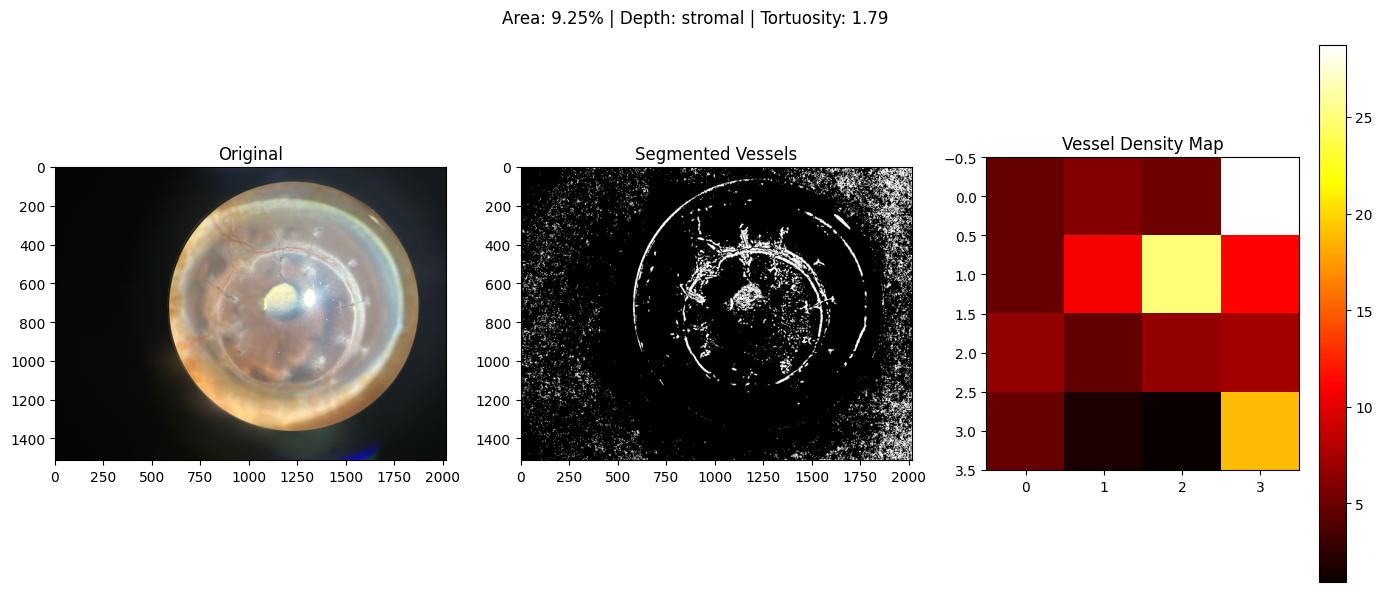

Vessel Area Percentage: 9.25%
Central Vessel Pixels Percentage: 11499.22%
Peripheral Vessel Pixels Percentage: 36080.47%
Superior Quadrant Vessel Pixels Percentage: 71707.03%
Inferior Quadrant Vessel Pixels Percentage: 38439.06%
Nasal Quadrant Vessel Pixels Percentage: 32857.42%
Temporal Quadrant Vessel Pixels Percentage: 77288.67%


In [11]:
results = analyze_corneal_neovascularization("/content/drive/MyDrive/Postpk Prabhakar.jpg")
total_pixels = results['density_map'].size * (results['density_map'].shape[0] * results['density_map'].shape[1]) # Approximate total pixels from density map size
print(f"Vessel Area Percentage: {results['vessel_percent']:.2f}%")
print(f"Central Vessel Pixels Percentage: {(results['central_vessel_pixels'] / total_pixels) * 100:.2f}%")
print(f"Peripheral Vessel Pixels Percentage: {(results['peripheral_vessel_pixels'] / total_pixels) * 100:.2f}%")
for quadrant, count in results['quadrant_vessel_counts'].items():
    print(f"{quadrant.capitalize()} Quadrant Vessel Pixels Percentage: {(count / total_pixels) * 100:.2f}%")